In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans


In [3]:
iris = load_iris()

In [4]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target
X.shape

(150, 4)

In [5]:
X = iris.data
y = iris.target

<Axes: >

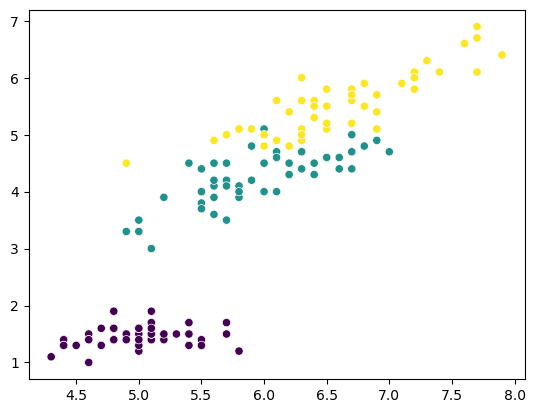

In [6]:
# Visualize 
sns.scatterplot(x=X[:,0],y=X[:,2],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# optional -  dimentionality reduction using pca
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

In [9]:
# Elbow Method
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)


<Axes: >

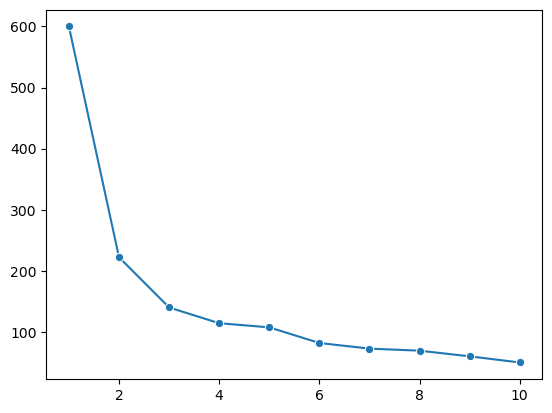

In [10]:
sns.lineplot(x=range(1,11),y=wcss,marker = 'o')

<Axes: >

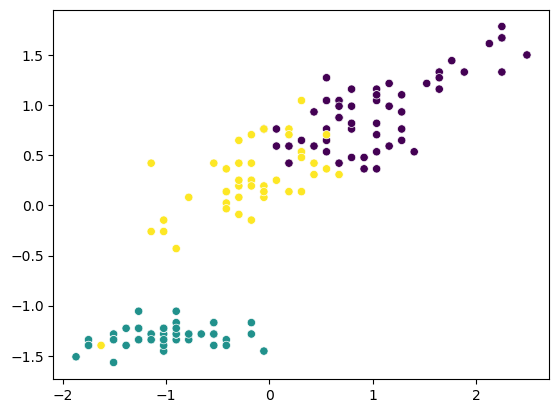

In [27]:
# KMeans
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,2],c=labels)

<Axes: >

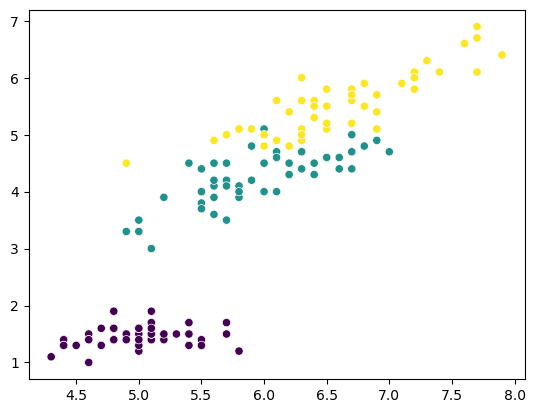

In [12]:
# Original Clusters
sns.scatterplot(x=X[:,0],y=X[:,2],c=y)

In [13]:
# Using PCA data
# Elbow Method
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)


<Axes: >

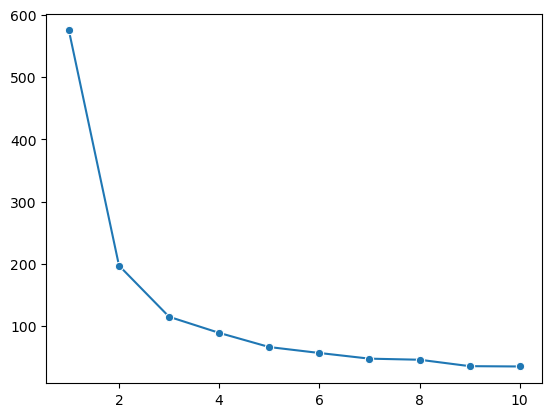

In [14]:
sns.lineplot(x=range(1,11),y=wcss,marker = 'o')

<Axes: >

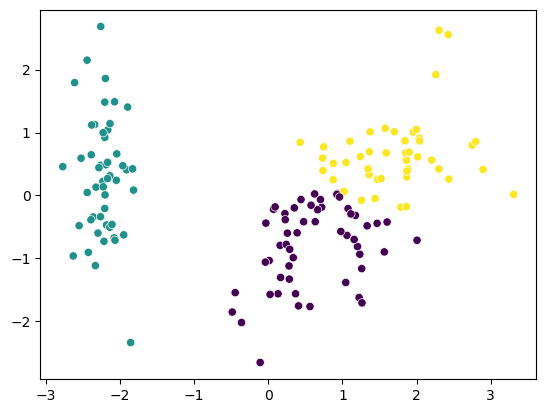

In [26]:
# KMeans
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)

<Axes: >

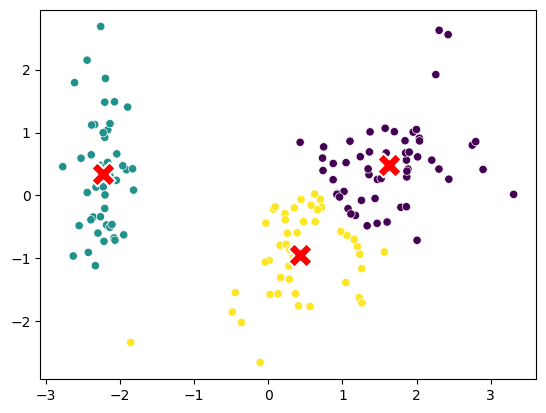

In [29]:
kmeans = KMeans(n_clusters=3,random_state=10)
labels = kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker='X',s=300,c="red")